In [2]:
import pandas as pd

df = pd.read_csv("/sales_data.csv", encoding="latin1")
print(df.shape)
df.head()

(20000, 17)


,order_id,order_date,customer_id,gender,age,region,city,category,product,unit_price,quantity,discount,sales,profit,channel,payment_method,rating
0,ORD100001,2023-01-01,C00543,Male,43,North,Jaipur,Beauty,Sunscreen,557,4,0.00,2228.0,164.59,Store,UPI,5.0
1,ORD100002,2023-01-01,C01001,Female,40,South,Bengaluru,Home & Kitchen,Table Lamp,851,2,0.05,1616.9,160.72,Online,Cash on Delivery,4.0
2,ORD100003,2023-01-01,C00224,Female,34,East,Bhubaneswar,Books & Stationery,Exam Guide,544,1,0.10,489.6,75.61,Mobile App,UPI,4.0
3,ORD100004,2023-01-01,C01603,Male,27,East,Bhubaneswar,Home & Kitchen,Bedsheet Set,916,5,0.00,4580.0,439.43,Mobile App,UPI,4.0
4,ORD100005,2023-01-01,C00248,Male,21,West,Mumbai,Beauty,Sunscreen,574,1,0.05,545.3,116.65,Store,UPI,NaN


In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(20000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20000 non-null  object 
 1   order_date      20000 non-null  object 
 2   customer_id     20000 non-null  object 
 3   gender          20000 non-null  object 
 4   age             20000 non-null  int64  
 5   region          20000 non-null  object 
 6   city            20000 non-null  object 
 7   category        20000 non-null  object 
 8   product         20000 non-null  object 
 9   unit_price      20000 non-null  int64  
 10  quantity        20000 non-null  int64  
 11  discount        20000 non-null  float64
 12  sales           20000 non-null  float64
 13  profit          20000 non-null  float64
 14  channel         20000 non-null  object 
 15  payment_method  20000 non-null  object 
 16  rating          19800 non-null  float64
dtypes: float64(4), int6

,0
order_id,0
order_date,0
customer_id,0
gender,0
age,0
region,0
city,0
category,0
product,0
unit_price,0


In [4]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.strftime("%Y-%m")

df.info()
df[["order_date", "month"]].head()

Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        20000 non-null  object        
 1   order_date      20000 non-null  datetime64[ns]
 2   customer_id     20000 non-null  object        
 3   gender          20000 non-null  object        
 4   age             20000 non-null  int64         
 5   region          20000 non-null  object        
 6   city            20000 non-null  object        
 7   category        20000 non-null  object        
 8   product         20000 non-null  object        
 9   unit_price      20000 non-null  int64         
 10  quantity        20000 non-null  int64         
 11  discount        20000 non-null  float64       
 12  sales           20000 non-null  float64       
 13  profit          20000 non-null  float64       
 14  channel         20000 non-null  object  

,order_date,month
0,2023-01-01,2023-01
1,2023-01-01,2023-01
2,2023-01-01,2023-01
3,2023-01-01,2023-01
4,2023-01-01,2023-01


In [5]:
# 1. Missing ratings
print("Missing ratings:", df["rating"].isnull().sum())

# 2. Look for wrong values (zero or negative)
print("Quantity <= 0:", (df["quantity"] <= 0).sum())
print("Sales <= 0:", (df["sales"] <= 0).sum())
print("Orders with loss (profit < 0):", (df["profit"] < 0).sum())

# 3. Check if sales is calculated correctly
check = df["unit_price"] * df["quantity"] * (1 - df["discount"])
print("Max difference in sales:", (check - df["sales"]).abs().max())

# 4. Summary of the number columns
df[["unit_price", "quantity", "discount", "sales", "profit"]].describe()

Missing ratings: 200
Quantity <= 0: 0
Sales <= 0: 0
Orders with loss (profit < 0): 387
Max difference in sales: 2.9103830456733704e-11


,unit_price,quantity,discount,sales,profit
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,5318.760050,2.24070,0.061780,11103.890837,1716.807179
std,12745.262927,1.40544,0.079938,32356.829928,5677.073726
min,134.000000,1.00000,0.000000,100.100000,-14749.630000
25%,515.000000,1.00000,0.000000,902.000000,101.840000
50%,1281.500000,2.00000,0.050000,2128.000000,288.420000
75%,2735.000000,3.00000,0.100000,5456.850000,835.327500
max,60496.000000,5.00000,0.300000,301935.000000,88059.090000


In [6]:
print("Total Sales:", round(df["sales"].sum()))
print("Total Profit:", round(df["profit"].sum()))
print("Profit Margin %:", round(df["profit"].sum() / df["sales"].sum() * 100, 2))
print("Total Orders:", df["order_id"].nunique())
print("Average Order Value:", round(df["sales"].sum() / df["order_id"].nunique()))

print("\nBy category:")
display(df.groupby("category")[["sales", "profit"]].sum().sort_values("profit", ascending=False))

print("By region:")
display(df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False))

print("By channel:")
display(df.groupby("channel")[["sales", "profit"]].sum().sort_values("sales", ascending=False))

Total Sales: 222077817
Total Profit: 34336144
Profit Margin %: 15.46
Total Orders: 20000
Average Order Value: 11104

By category:


,sales,profit
category,,
Electronics,1.868937e+08,28821643.94
Clothing,1.635561e+07,2531359.47
Home & Kitchen,1.222447e+07,1935618.68
Beauty,3.829043e+06,596301.06
Books & Stationery,2.774972e+06,451220.43


By region:


,sales,profit
region,,
South,70069874.35,10727611.79
North,58178511.80,9188104.42
West,56941521.00,8923886.81
East,36887909.60,5496540.56


By channel:


,sales,profit
channel,,
Online,1.001131e+08,15653916.38
Store,6.854909e+07,10566309.08
Mobile App,5.341567e+07,8115918.12


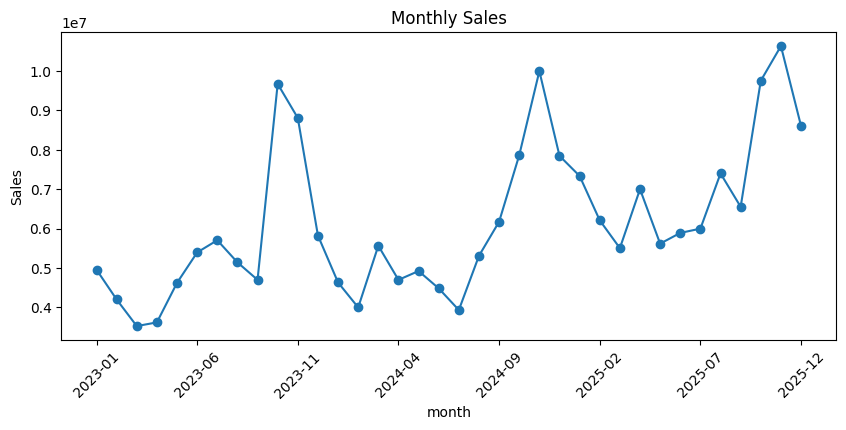

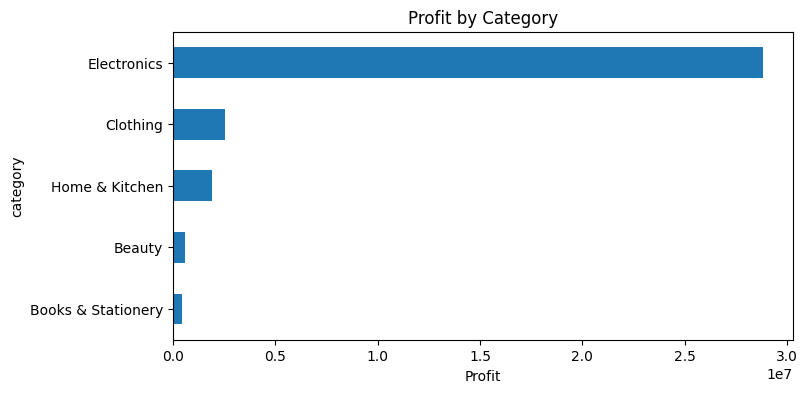

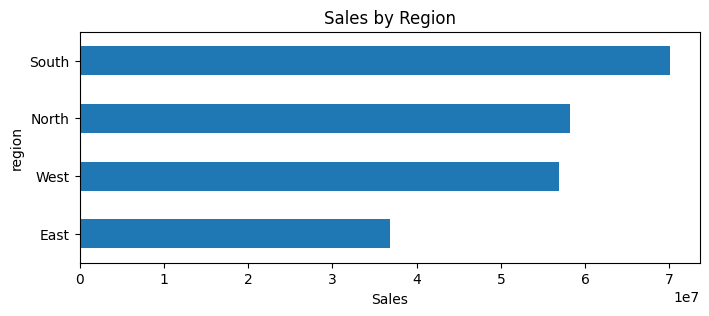

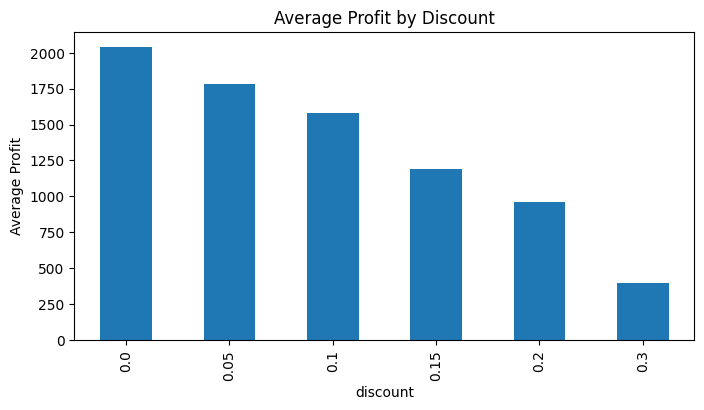

In [7]:
import matplotlib.pyplot as plt

# Chart 1: Monthly sales trend
df.groupby("month")["sales"].sum().plot(kind="line", marker="o", figsize=(10, 4), title="Monthly Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Chart 2: Profit by category
df.groupby("category")["profit"].sum().sort_values().plot(kind="barh", figsize=(8, 4), title="Profit by Category")
plt.xlabel("Profit")
plt.show()

# Chart 3: Sales by region
df.groupby("region")["sales"].sum().sort_values().plot(kind="barh", figsize=(8, 3), title="Sales by Region")
plt.xlabel("Sales")
plt.show()

# Chart 4: Average profit by discount level
df.groupby("discount")["profit"].mean().plot(kind="bar", figsize=(8, 4), title="Average Profit by Discount")
plt.ylabel("Average Profit")
plt.show()

In [8]:
def make_report(input_file, output_file="/monthly_sales_report.xlsx"):
    data = pd.read_csv(input_file, encoding="latin1")
    data = data.drop_duplicates()
    data["order_date"] = pd.to_datetime(data["order_date"])
    data["month"] = data["order_date"].dt.strftime("%Y-%m")

    total_sales = data["sales"].sum()
    total_profit = data["profit"].sum()
    total_orders = data["order_id"].nunique()

    summary = pd.DataFrame({
        "KPI": ["Total Sales", "Total Profit", "Profit Margin %", "Total Orders", "Average Order Value"],
        "Value": [round(total_sales), round(total_profit),
                  round(total_profit / total_sales * 100, 2),
                  total_orders, round(total_sales / total_orders)]
    })

    monthly = data.groupby("month")[["sales", "profit"]].sum().reset_index()
    by_category = data.groupby("category")[["sales", "profit"]].sum().sort_values("sales", ascending=False).reset_index()
    by_region = data.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False).reset_index()
    by_channel = data.groupby("channel")[["sales", "profit"]].sum().sort_values("sales", ascending=False).reset_index()

    with pd.ExcelWriter(output_file) as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        monthly.to_excel(writer, sheet_name="Monthly", index=False)
        by_category.to_excel(writer, sheet_name="By Category", index=False)
        by_region.to_excel(writer, sheet_name="By Region", index=False)
        by_channel.to_excel(writer, sheet_name="By Channel", index=False)

    print("Report saved:", output_file)

make_report("/sales_data.csv")

Report saved: /monthly_sales_report.xlsx


In [9]:
print(df.groupby("discount")["profit"].agg(["count", "mean"]))
print("\nLoss-making orders by discount:")
print(df[df["profit"] < 0].groupby("discount")["profit"].count())

          count         mean
discount                    
0.00       9988  2042.257623
0.05       2995  1780.139803
0.10       2997  1581.975052
0.15       1973  1192.885813
0.20       1239   962.351663
0.30        808   395.370149

Loss-making orders by discount:
discount
0.15     14
0.20    107
0.30    266
Name: profit, dtype: int64
